# Sorting Algorithms — Regression Analysis & Predictions
Fits theoretical complexity curves to benchmark data and predicts performance for larger `n`.

Blue = Random | Green = Sorted | Red = Reversed

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import pearsonr

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [ ]:
try:
    df = pd.read_csv('sorting-results.csv', encoding='utf-16')
except UnicodeError:
    df = pd.read_csv('sorting-results.csv', encoding='utf-8')

print(f'Loaded {len(df)} rows')
print(f'Algorithms : {sorted(df["algorithm"].unique())}')
print(f'Cases      : {sorted(df["case"].unique())}')
print(f'n range    : {df["n"].min()} – {df["n"].max()}')
df.head()

In [8]:
# ── Theoretical complexity functions ─────────────────────────────────────────

def model_n2(n, a, b, c):
    """O(n²)  — Swap, Bubble, Selection, Insertion, Cocktail, Gnome"""
    return a * n**2 + b * n + c

def model_nlogn(n, a, b, c):
    """O(n log n)  — Merge, Heap, Intro, Tim, Quick, Tree, Comb"""
    return a * n * np.log2(n) + b * n + c

def model_n_log2n(n, a, b):
    """O(n log² n)  — Bitonic, Shell"""
    return a * n * np.log2(n)**2 + b

def model_n(n, a, b):
    """O(n)  — Count, Radix, Pigeonhole, Bucket"""
    return a * n + b

ALGO_MODEL = {
    'Swap Sort'        : (model_n2,      'O(n²)'),
    'Bubble Sort'      : (model_n2,      'O(n²)'),
    'Selection Sort'   : (model_n2,      'O(n²)'),
    'Insertion Sort'   : (model_n2,      'O(n²)'),
    'Cocktail Sort'    : (model_n2,      'O(n²)'),
    'Gnome Sort'       : (model_n2,      'O(n²)'),
    'Merge Sort'       : (model_nlogn,   'O(n log n)'),
    'Heap Sort'        : (model_nlogn,   'O(n log n)'),
    'Intro Sort'       : (model_nlogn,   'O(n log n)'),
    'Tim Sort'         : (model_nlogn,   'O(n log n)'),
    'Quick Sort (Rec)' : (model_nlogn,   'O(n log n)'),
    'Quick Sort (Iter)': (model_nlogn,   'O(n log n)'),
    'Tree Sort'        : (model_nlogn,   'O(n log n)'),
    'Comb Sort'        : (model_nlogn,   'O(n log n)'),
    'Shell Sort'       : (model_n_log2n, 'O(n log² n)'),
    'Bitonic Sort'     : (model_n_log2n, 'O(n log² n)'),
    'Count Sort'       : (model_n,       'O(n)'),
    'Radix Sort'       : (model_n,       'O(n)'),
    'Pigeonhole Sort'  : (model_n,       'O(n)'),
    'Bucket Sort'      : (model_n,       'O(n)'),
}

CASE_COLORS = {
    'random'  : '#2196F3',
    'sorted'  : '#4CAF50',
    'reversed': '#F44336',
}

def fit_and_plot(algorithm, ax_time, ax_count, n_predict_max=1_000_000, n_steps=500):
    model_fn, complexity_label = ALGO_MODEL[algorithm]

    sub = df[df['algorithm'] == algorithm].copy()
    if sub.empty:
        print(f'No data for: {algorithm}')
        return

    cases_present = sub['case'].unique()
    n_dense       = np.linspace(sub['n'].min(), n_predict_max, n_steps)
    n_data_max    = sub['n'].max()

    for case in ['random', 'sorted', 'reversed']:
        if case not in cases_present:
            continue

        data_case = sub[sub['case'] == case].sort_values('n')
        n_vals   = data_case['n'].values.astype(float)
        t_vals   = data_case['time_ms'].values.astype(float)
        c_vals   = data_case['count'].values.astype(float)
        color    = CASE_COLORS[case]
        label    = case.capitalize()
        n_params = model_fn.__code__.co_argcount - 1

        try:
            popt_t, _ = curve_fit(model_fn, n_vals, t_vals,
                                  maxfev=10_000, p0=[1e-6] * n_params)
            t_fitted  = model_fn(n_dense, *popt_t)
            r2_t      = pearsonr(t_vals, model_fn(n_vals, *popt_t))[0] ** 2
            ax_time.plot(n_dense, t_fitted, color=color, linewidth=2,
                         linestyle='--', label=f'{label}  (R²={r2_t:.4f})')
        except RuntimeError:
            pass

        try:
            popt_c, _ = curve_fit(model_fn, n_vals, c_vals,
                                  maxfev=10_000, p0=[1e-6] * n_params)
            c_fitted  = model_fn(n_dense, *popt_c)
            r2_c      = pearsonr(c_vals, model_fn(n_vals, *popt_c))[0] ** 2
            ax_count.plot(n_dense, c_fitted, color=color, linewidth=2,
                          linestyle='--', label=f'{label}  (R²={r2_c:.4f})')
        except RuntimeError:
            pass

    count_type  = sub['count_type'].iloc[0]
    count_label = 'Swaps' if count_type == 'sw' else 'Element Writes'

    for ax in (ax_time, ax_count):
        ax.axvline(n_data_max, color='gray', linestyle=':', linewidth=1,
                   label=f'Data boundary (n={n_data_max:,})')
        ax.legend(fontsize=8, framealpha=0.4)
        ax.set_xlabel('n  (input size)', fontsize=10)
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:,.0f}'))

    ax_time.set_title(f'{algorithm}  [{complexity_label}]  — Time (ms)',
                      fontsize=11, fontweight='bold')
    ax_time.set_ylabel('time_ms', fontsize=10)
    ax_count.set_title(f'{algorithm}  [{complexity_label}]  — {count_label}',
                       fontsize=11, fontweight='bold')
    ax_count.set_ylabel(count_label, fontsize=10)

print('Models and fit_and_plot() ready.')

C:\Users\sebig\AppData\Local\Temp\ipykernel_9504\2243927578.py:83: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_c, _ = curve_fit(model_fn, n_vals, c_vals,
C:\Users\sebig\AppData\Local\Temp\ipykernel_9504\2243927578.py:86: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r2_c      = pearsonr(c_vals, model_fn(n_vals, *popt_c))[0] ** 2


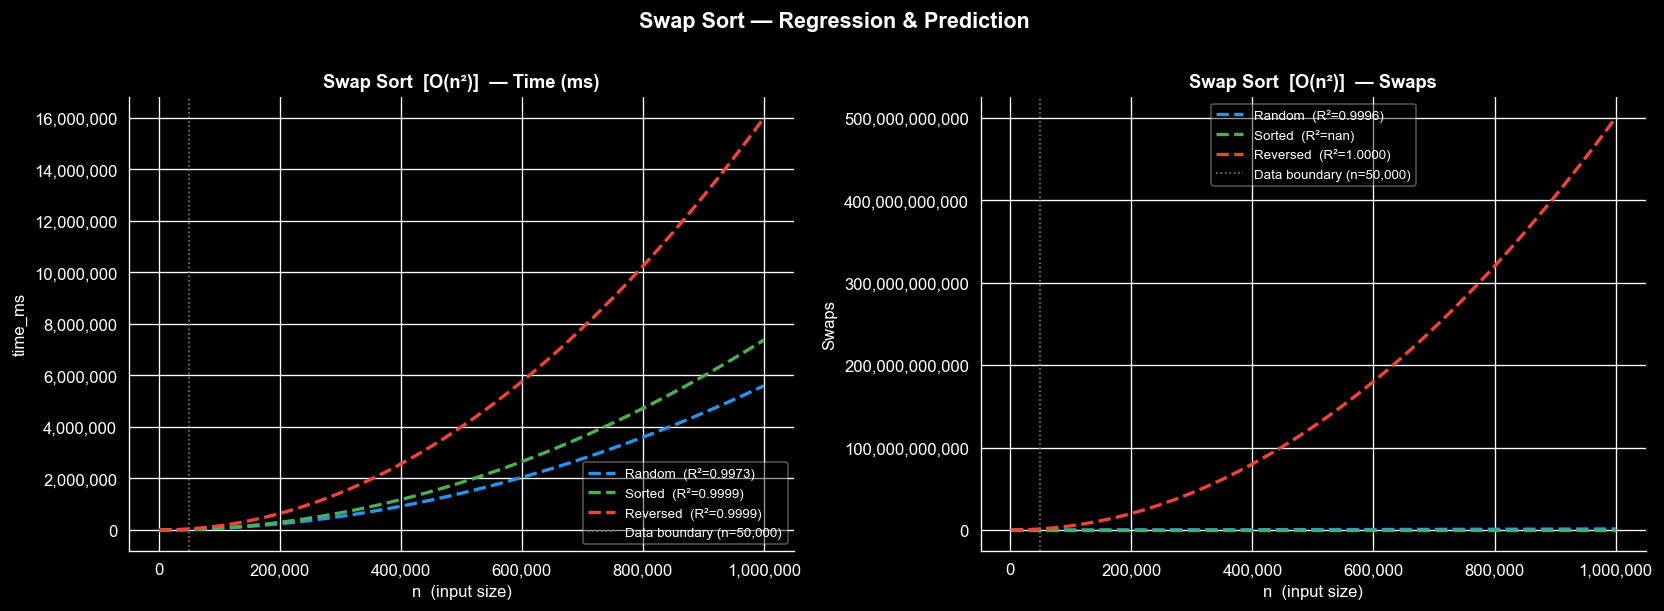

In [9]:
# ── Swap Sort ──
fig, (ax_t, ax_c) = plt.subplots(1, 2, figsize=(14, 5))
fit_and_plot('Swap Sort', ax_t, ax_c)
fig.suptitle('Swap Sort — Regression & Prediction', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

C:\Users\sebig\AppData\Local\Temp\ipykernel_9504\2243927578.py:83: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_c, _ = curve_fit(model_fn, n_vals, c_vals,
C:\Users\sebig\AppData\Local\Temp\ipykernel_9504\2243927578.py:86: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r2_c      = pearsonr(c_vals, model_fn(n_vals, *popt_c))[0] ** 2


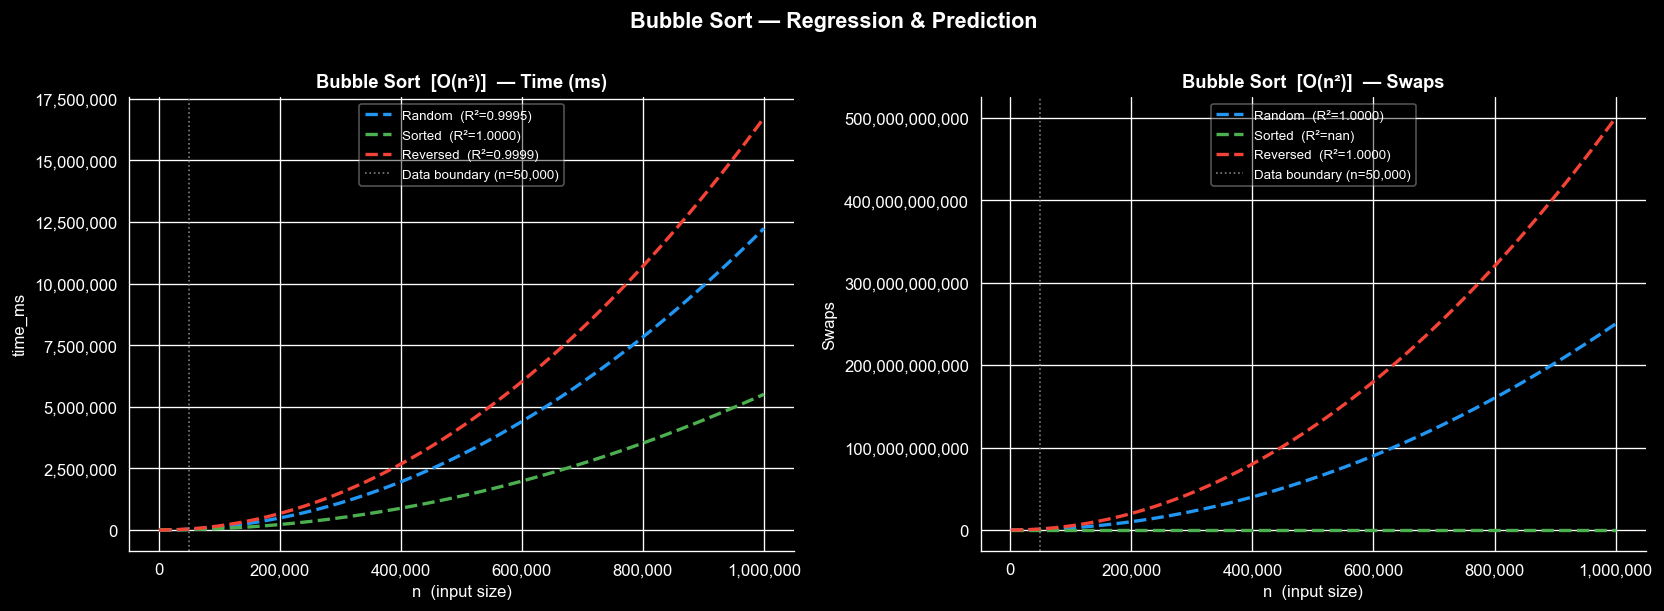

In [10]:
# ── Bubble Sort ──
fig, (ax_t, ax_c) = plt.subplots(1, 2, figsize=(14, 5))
fit_and_plot('Bubble Sort', ax_t, ax_c)
fig.suptitle('Bubble Sort — Regression & Prediction', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

C:\Users\sebig\AppData\Local\Temp\ipykernel_9504\2243927578.py:86: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r2_c      = pearsonr(c_vals, model_fn(n_vals, *popt_c))[0] ** 2


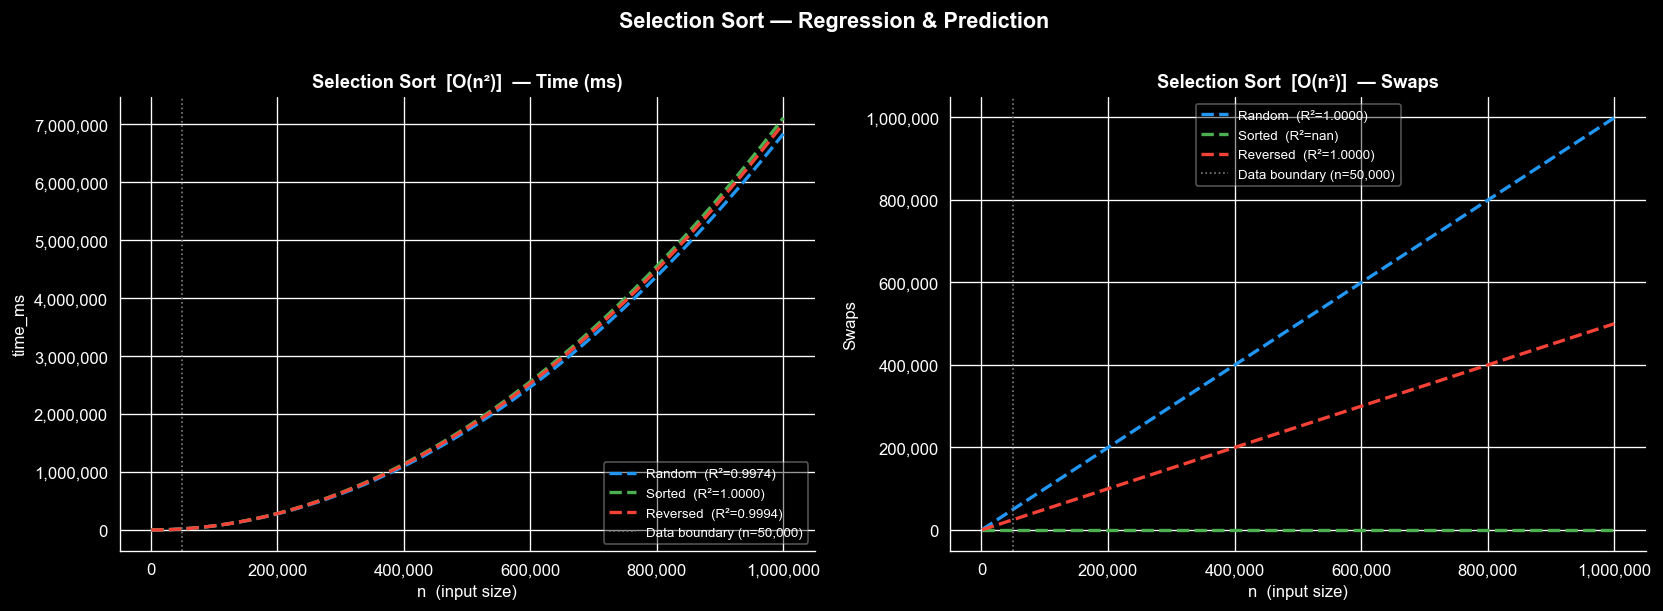

In [11]:
# ── Selection Sort ──
fig, (ax_t, ax_c) = plt.subplots(1, 2, figsize=(14, 5))
fit_and_plot('Selection Sort', ax_t, ax_c)
fig.suptitle('Selection Sort — Regression & Prediction', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

C:\Users\sebig\AppData\Local\Temp\ipykernel_9504\2243927578.py:83: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_c, _ = curve_fit(model_fn, n_vals, c_vals,


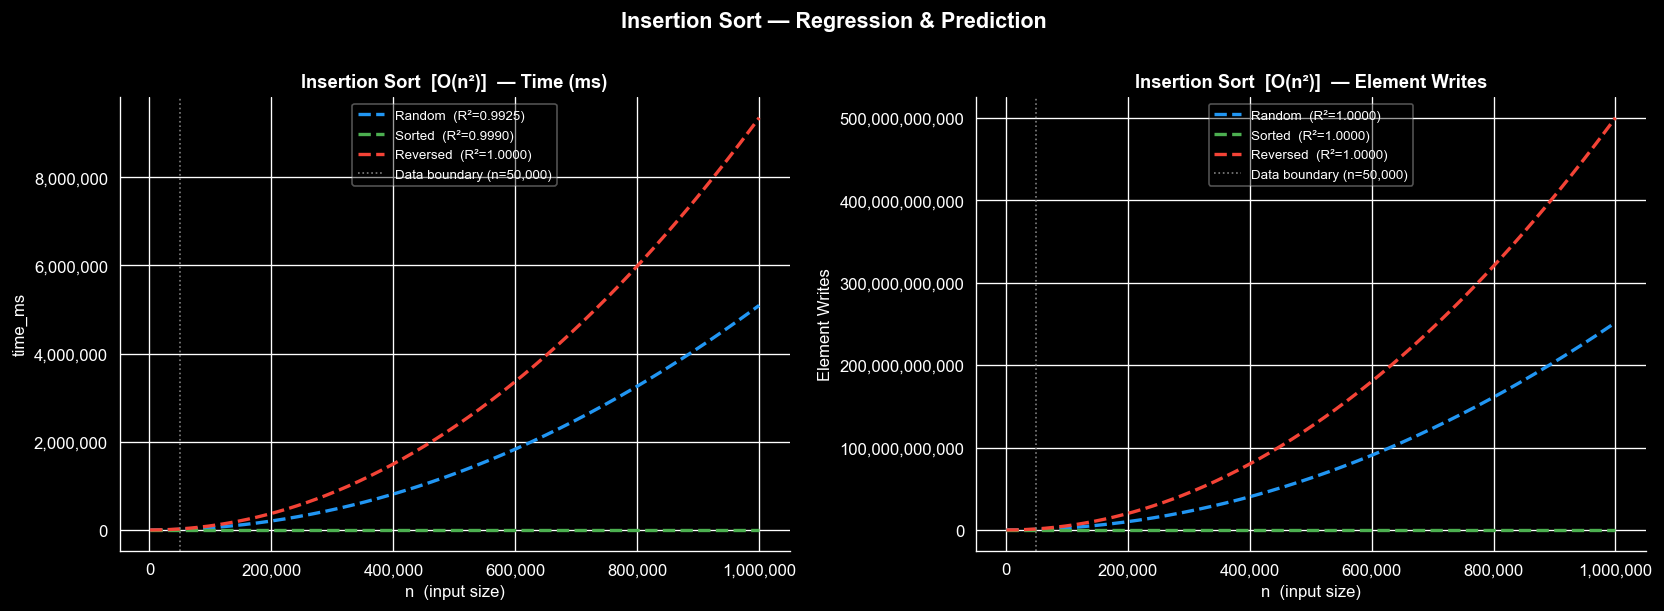

In [12]:
# ── Insertion Sort ──
fig, (ax_t, ax_c) = plt.subplots(1, 2, figsize=(14, 5))
fit_and_plot('Insertion Sort', ax_t, ax_c)
fig.suptitle('Insertion Sort — Regression & Prediction', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

C:\Users\sebig\AppData\Local\Temp\ipykernel_9504\2243927578.py:83: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_c, _ = curve_fit(model_fn, n_vals, c_vals,


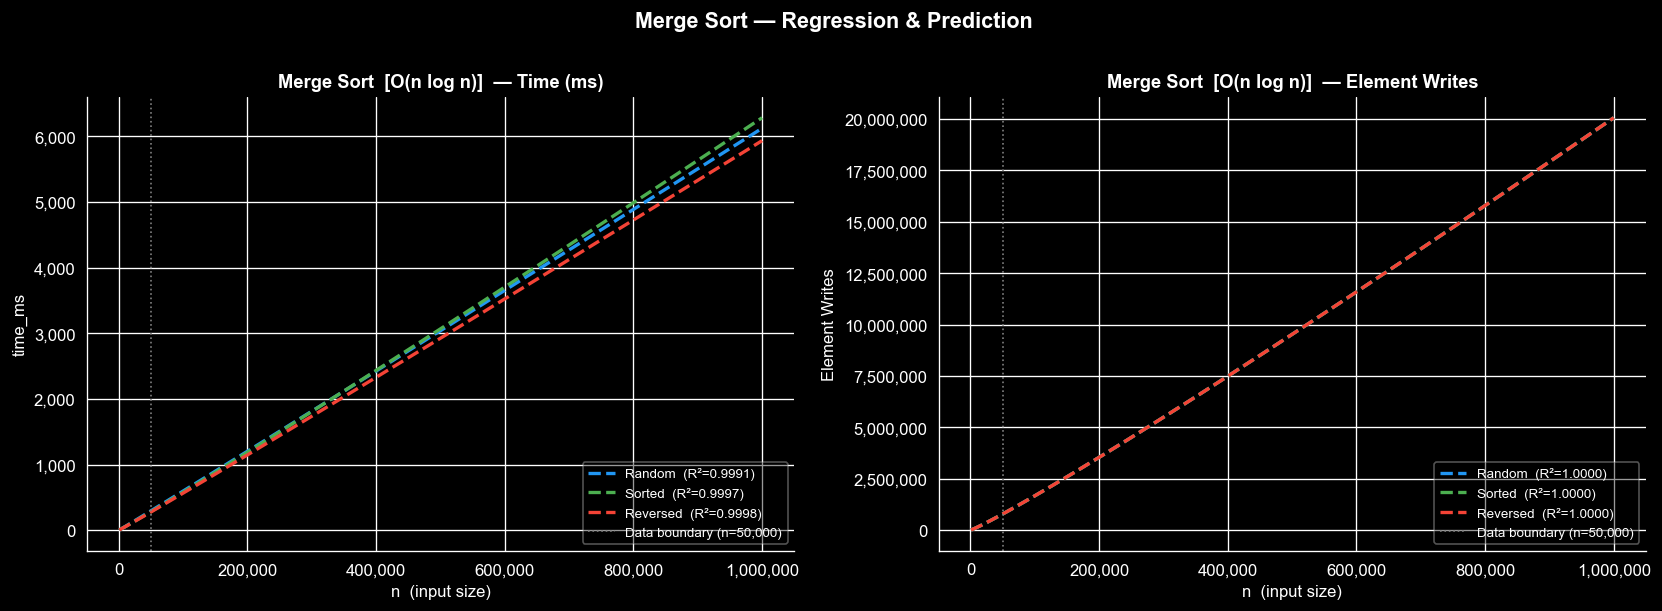

In [13]:
# ── Merge Sort ──
fig, (ax_t, ax_c) = plt.subplots(1, 2, figsize=(14, 5))
fit_and_plot('Merge Sort', ax_t, ax_c)
fig.suptitle('Merge Sort — Regression & Prediction', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

C:\Users\sebig\AppData\Local\Temp\ipykernel_9504\2243927578.py:83: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_c, _ = curve_fit(model_fn, n_vals, c_vals,


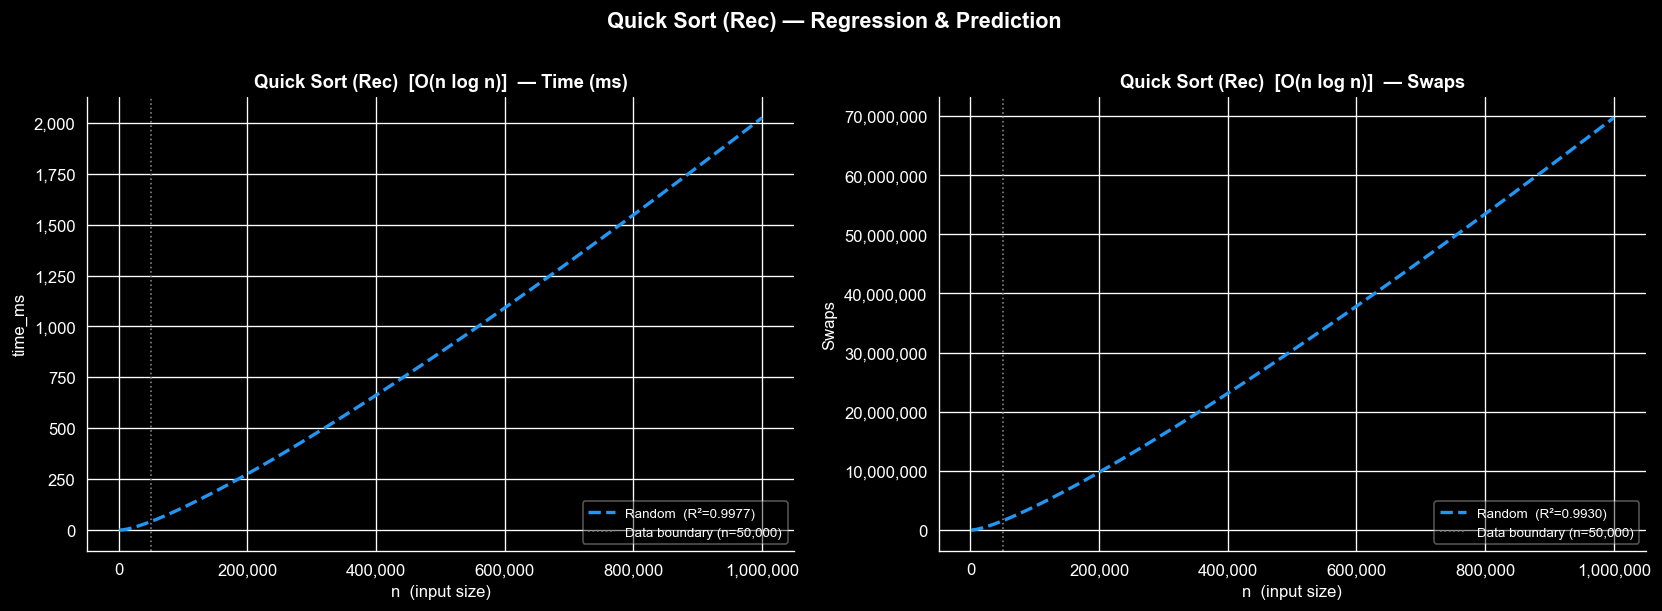

In [14]:
# ── Quick Sort (Rec) ──
fig, (ax_t, ax_c) = plt.subplots(1, 2, figsize=(14, 5))
fit_and_plot('Quick Sort (Rec)', ax_t, ax_c)
fig.suptitle('Quick Sort (Rec) — Regression & Prediction', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

C:\Users\sebig\AppData\Local\Temp\ipykernel_9504\2243927578.py:83: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_c, _ = curve_fit(model_fn, n_vals, c_vals,


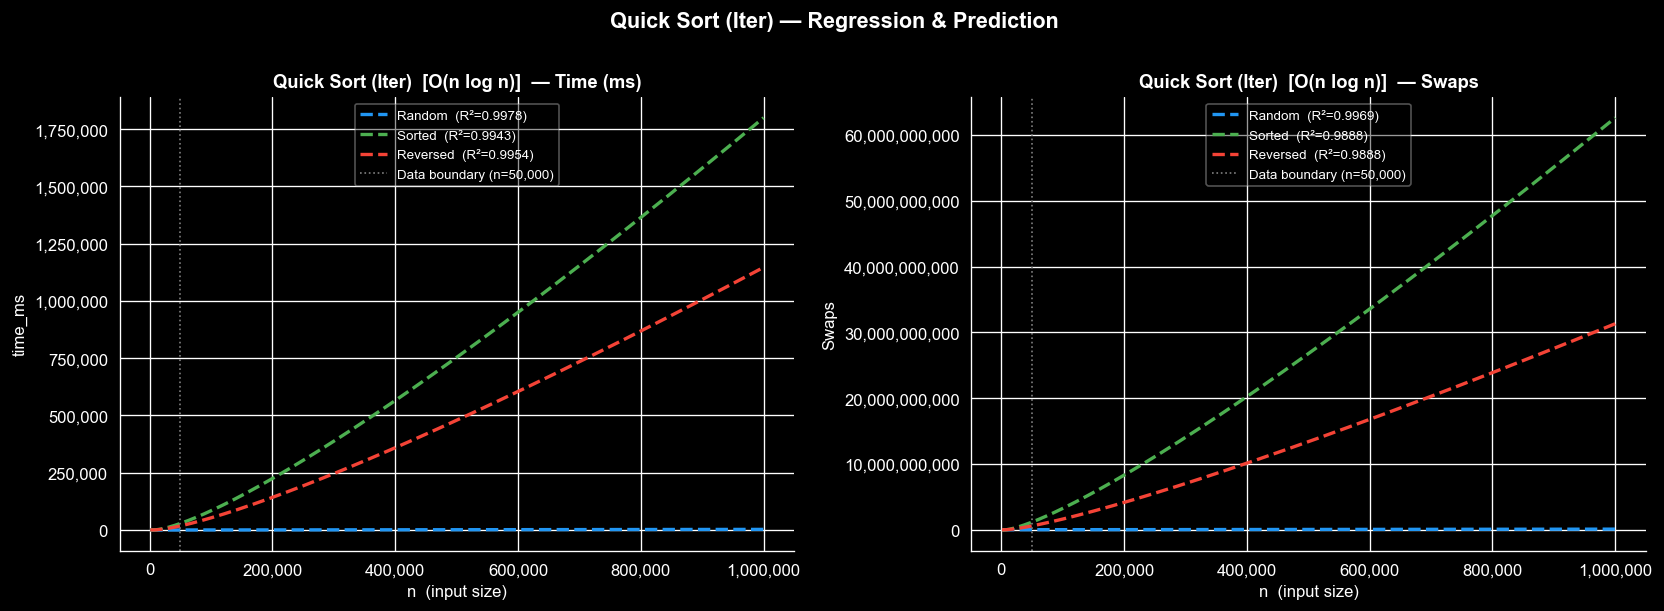

In [15]:
# ── Quick Sort (Iter) ──
fig, (ax_t, ax_c) = plt.subplots(1, 2, figsize=(14, 5))
fit_and_plot('Quick Sort (Iter)', ax_t, ax_c)
fig.suptitle('Quick Sort (Iter) — Regression & Prediction', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

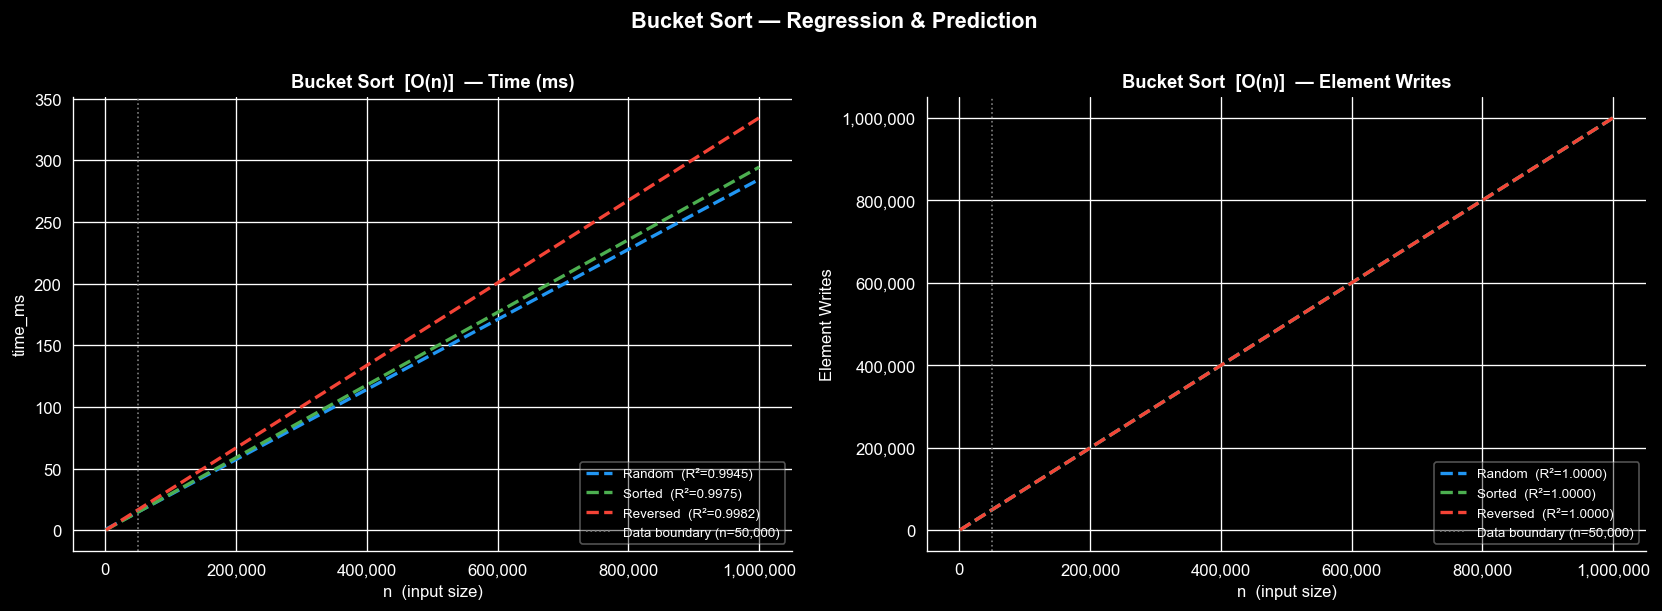

In [16]:
# ── Bucket Sort ──
fig, (ax_t, ax_c) = plt.subplots(1, 2, figsize=(14, 5))
fit_and_plot('Bucket Sort', ax_t, ax_c)
fig.suptitle('Bucket Sort — Regression & Prediction', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

C:\Users\sebig\AppData\Local\Temp\ipykernel_9504\2243927578.py:83: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_c, _ = curve_fit(model_fn, n_vals, c_vals,


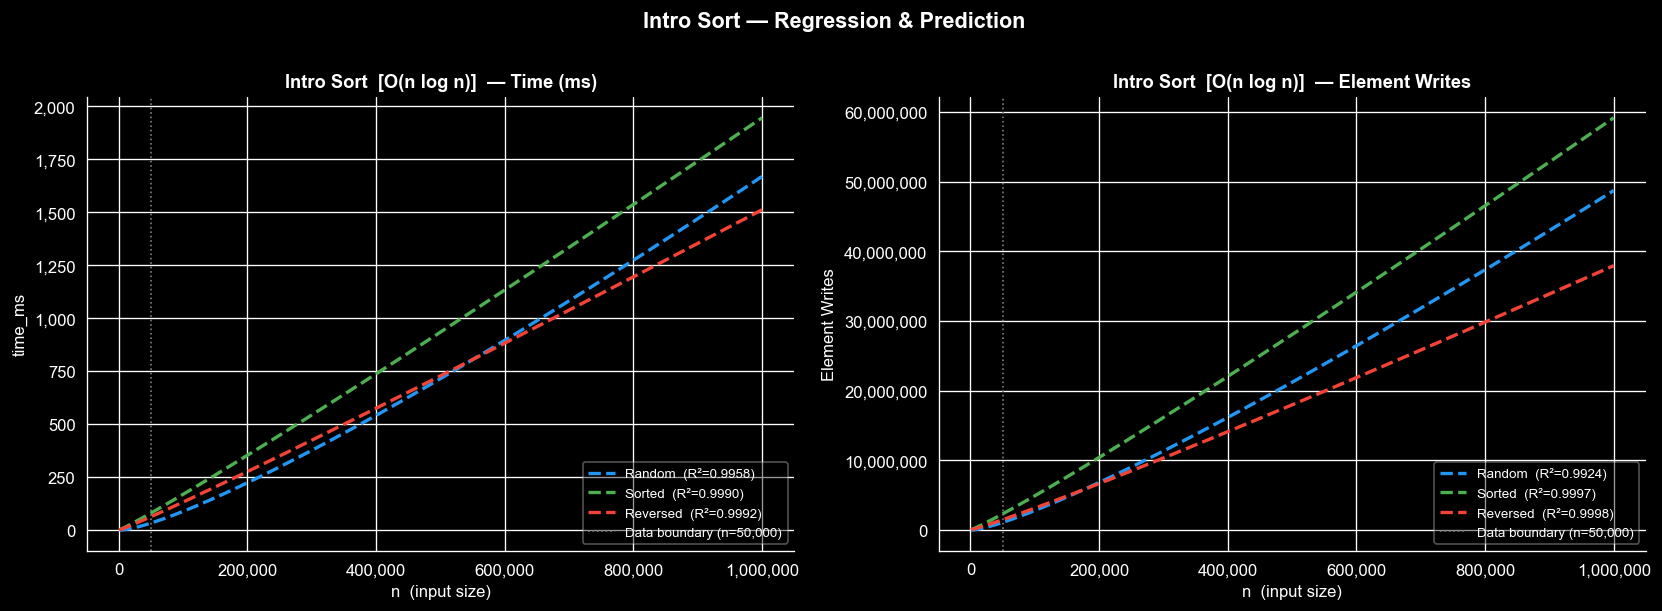

In [17]:
# ── Intro Sort ──
fig, (ax_t, ax_c) = plt.subplots(1, 2, figsize=(14, 5))
fit_and_plot('Intro Sort', ax_t, ax_c)
fig.suptitle('Intro Sort — Regression & Prediction', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

C:\Users\sebig\AppData\Local\Temp\ipykernel_9504\2243927578.py:83: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_c, _ = curve_fit(model_fn, n_vals, c_vals,


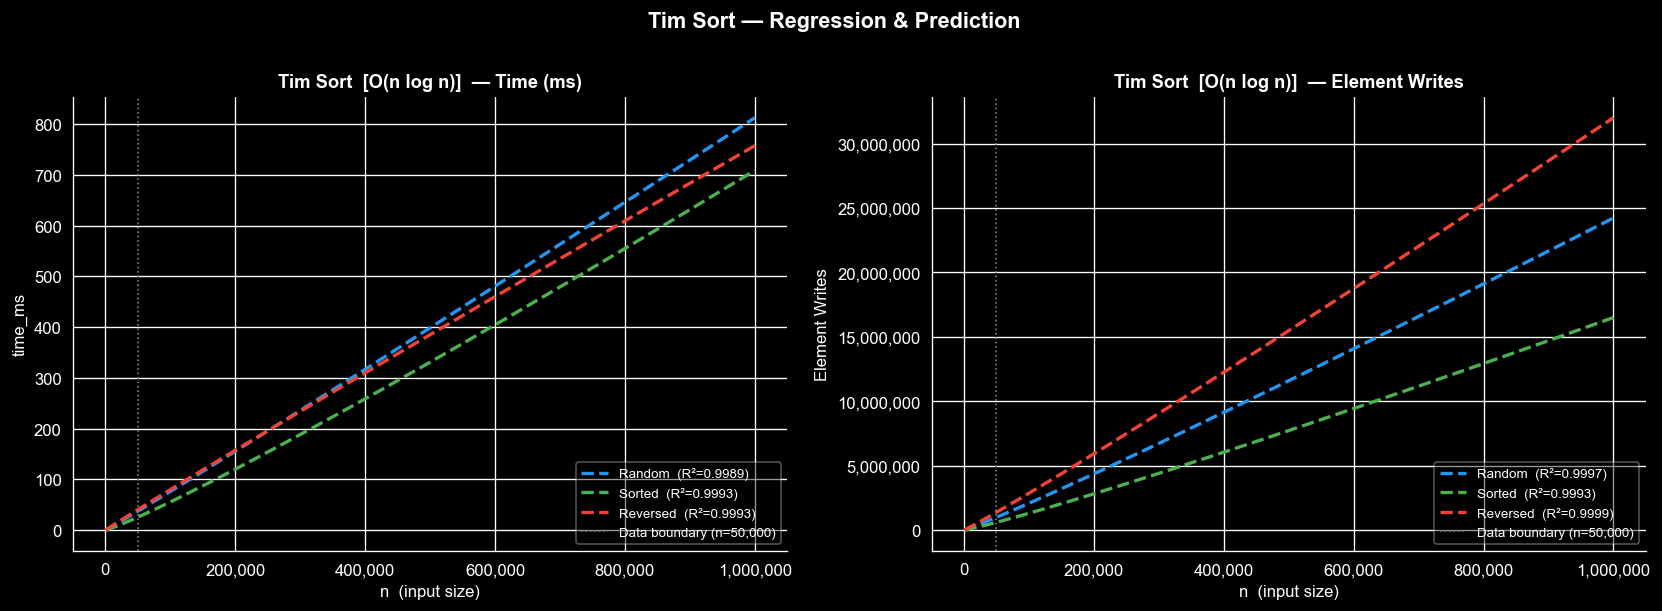

In [18]:
# ── Tim Sort ──
fig, (ax_t, ax_c) = plt.subplots(1, 2, figsize=(14, 5))
fit_and_plot('Tim Sort', ax_t, ax_c)
fig.suptitle('Tim Sort — Regression & Prediction', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

C:\Users\sebig\AppData\Local\Temp\ipykernel_9504\2243927578.py:86: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r2_c      = pearsonr(c_vals, model_fn(n_vals, *popt_c))[0] ** 2


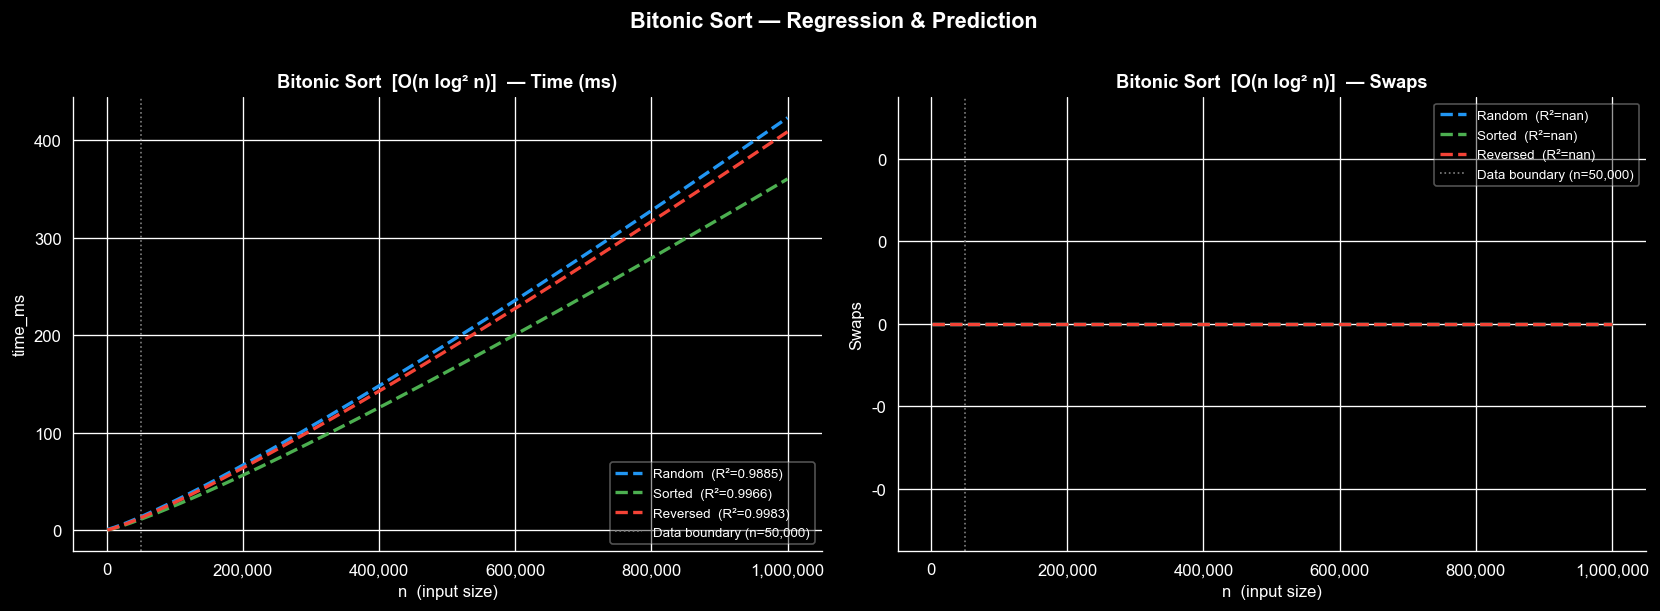

In [19]:
# ── Bitonic Sort ──
fig, (ax_t, ax_c) = plt.subplots(1, 2, figsize=(14, 5))
fit_and_plot('Bitonic Sort', ax_t, ax_c)
fig.suptitle('Bitonic Sort — Regression & Prediction', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

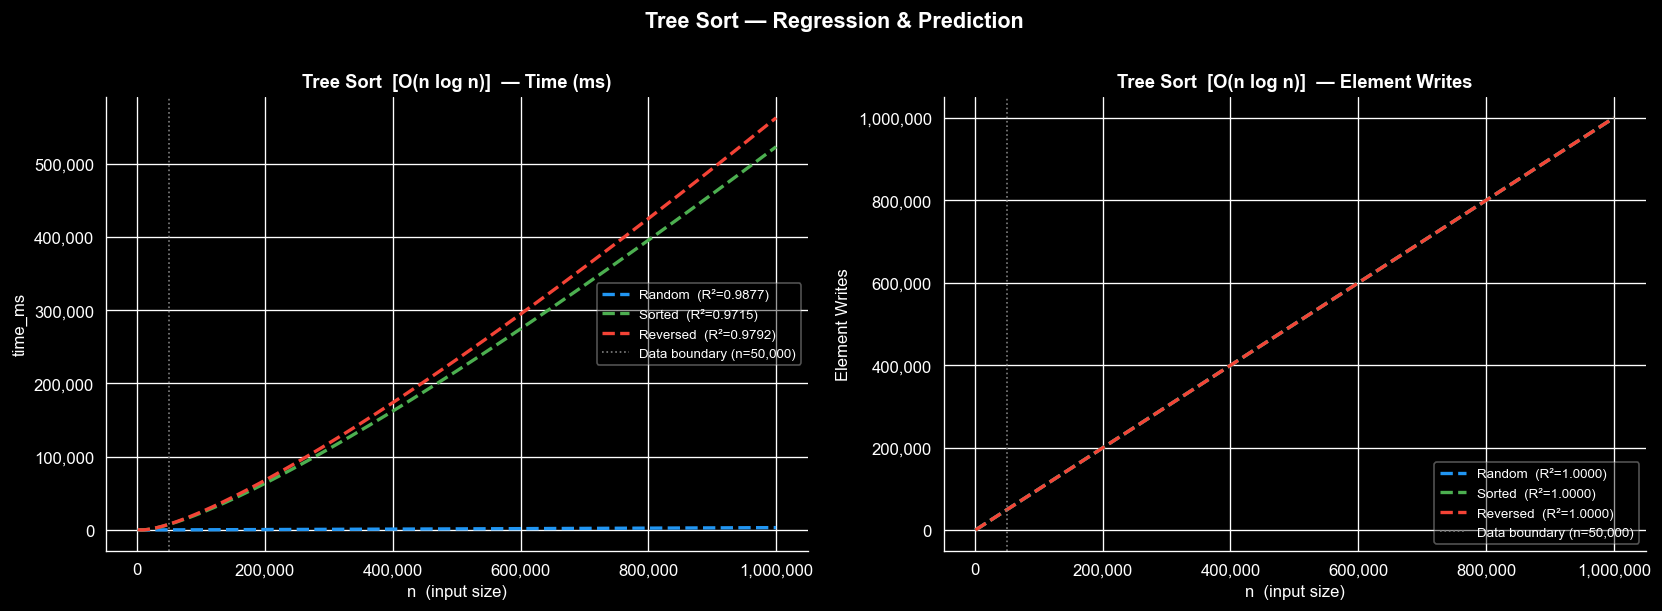

In [20]:
# ── Tree Sort ──
fig, (ax_t, ax_c) = plt.subplots(1, 2, figsize=(14, 5))
fit_and_plot('Tree Sort', ax_t, ax_c)
fig.suptitle('Tree Sort — Regression & Prediction', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

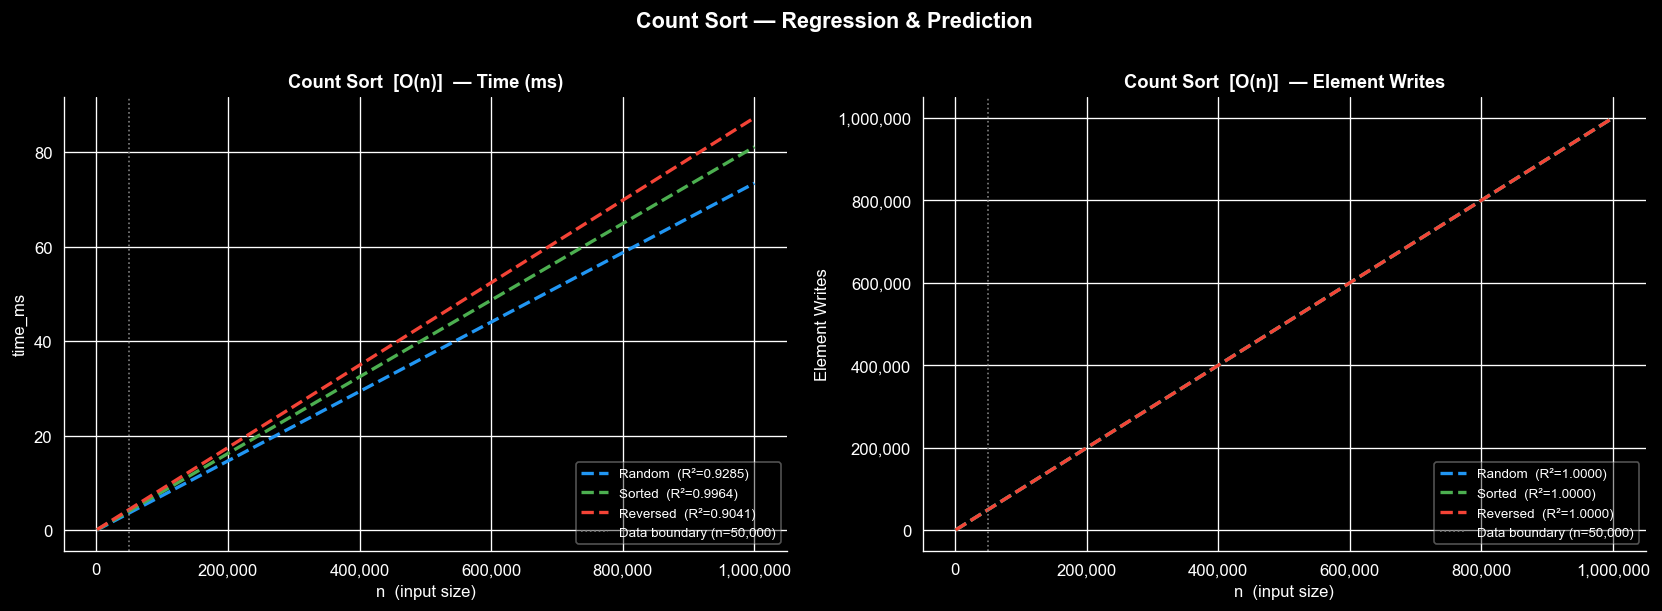

In [21]:
# ── Count Sort ──
fig, (ax_t, ax_c) = plt.subplots(1, 2, figsize=(14, 5))
fit_and_plot('Count Sort', ax_t, ax_c)
fig.suptitle('Count Sort — Regression & Prediction', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

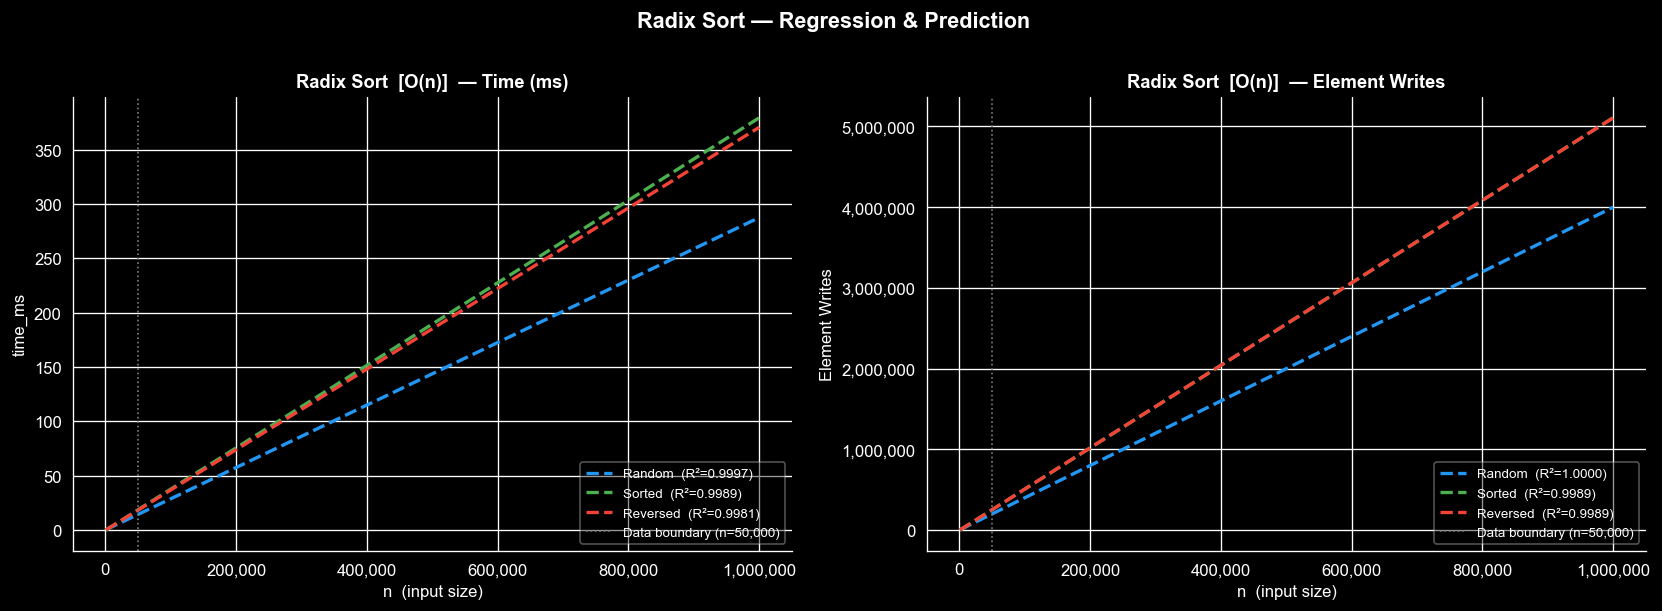

In [22]:
# ── Radix Sort ──
fig, (ax_t, ax_c) = plt.subplots(1, 2, figsize=(14, 5))
fit_and_plot('Radix Sort', ax_t, ax_c)
fig.suptitle('Radix Sort — Regression & Prediction', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

C:\Users\sebig\AppData\Local\Temp\ipykernel_9504\2243927578.py:83: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_c, _ = curve_fit(model_fn, n_vals, c_vals,


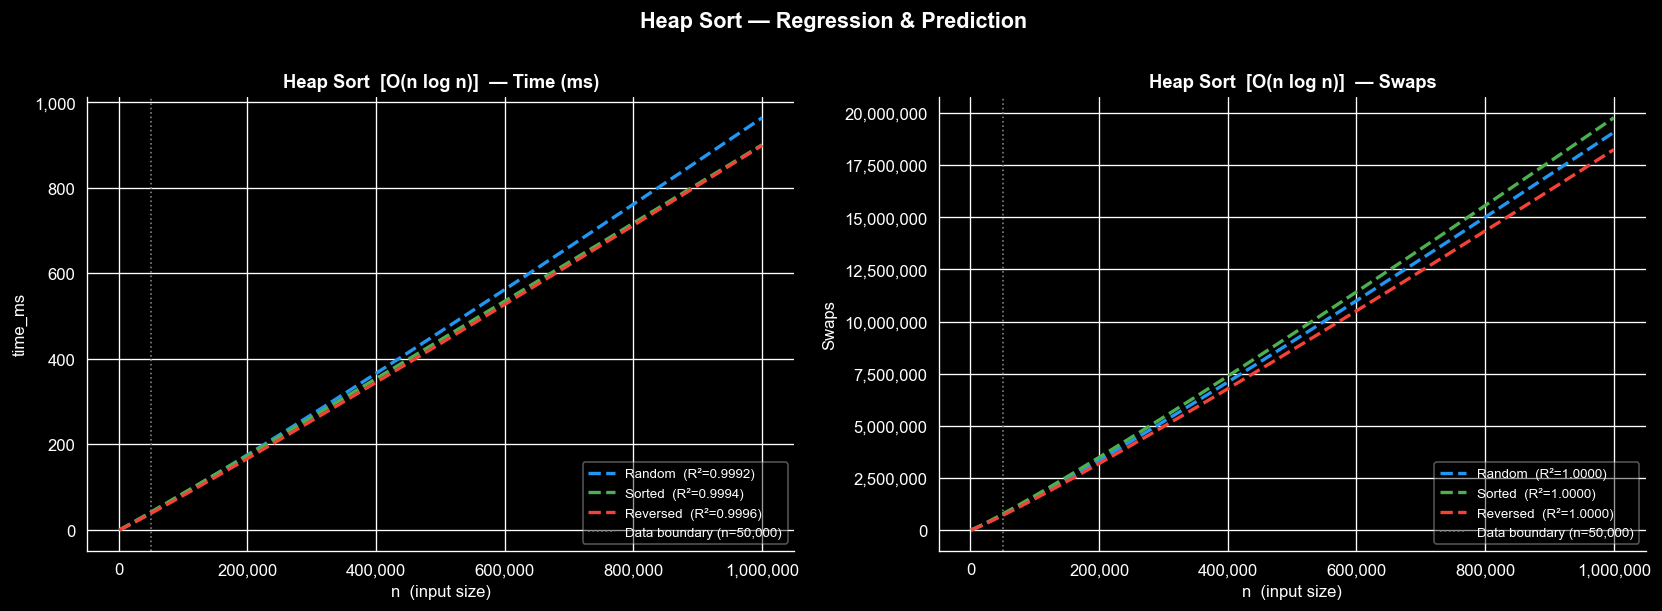

In [23]:
# ── Heap Sort ──
fig, (ax_t, ax_c) = plt.subplots(1, 2, figsize=(14, 5))
fit_and_plot('Heap Sort', ax_t, ax_c)
fig.suptitle('Heap Sort — Regression & Prediction', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

C:\Users\sebig\AppData\Local\Temp\ipykernel_9504\2243927578.py:83: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_c, _ = curve_fit(model_fn, n_vals, c_vals,


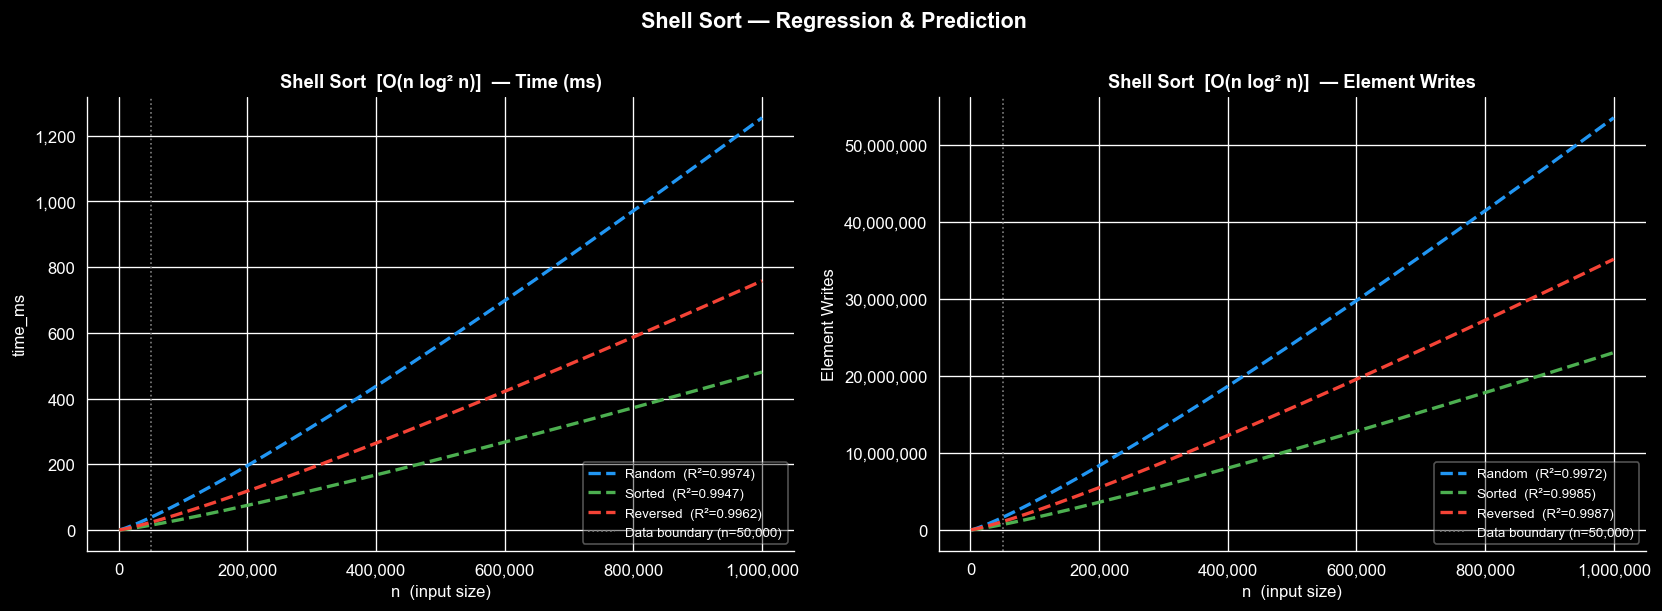

In [24]:
# ── Shell Sort ──
fig, (ax_t, ax_c) = plt.subplots(1, 2, figsize=(14, 5))
fit_and_plot('Shell Sort', ax_t, ax_c)
fig.suptitle('Shell Sort — Regression & Prediction', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

C:\Users\sebig\AppData\Local\Temp\ipykernel_9504\2243927578.py:83: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_c, _ = curve_fit(model_fn, n_vals, c_vals,
C:\Users\sebig\AppData\Local\Temp\ipykernel_9504\2243927578.py:86: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r2_c      = pearsonr(c_vals, model_fn(n_vals, *popt_c))[0] ** 2


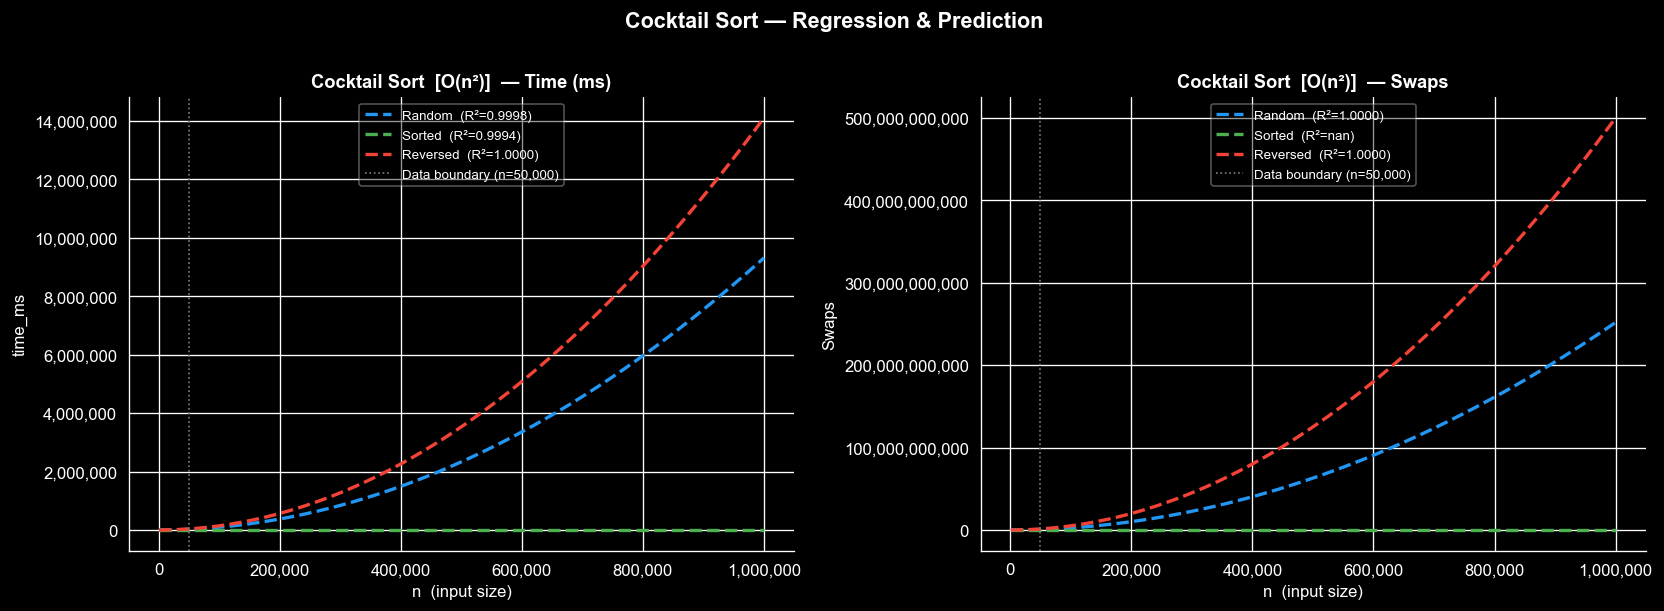

In [25]:
# ── Cocktail Sort ──
fig, (ax_t, ax_c) = plt.subplots(1, 2, figsize=(14, 5))
fit_and_plot('Cocktail Sort', ax_t, ax_c)
fig.suptitle('Cocktail Sort — Regression & Prediction', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

C:\Users\sebig\AppData\Local\Temp\ipykernel_9504\2243927578.py:86: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r2_c      = pearsonr(c_vals, model_fn(n_vals, *popt_c))[0] ** 2


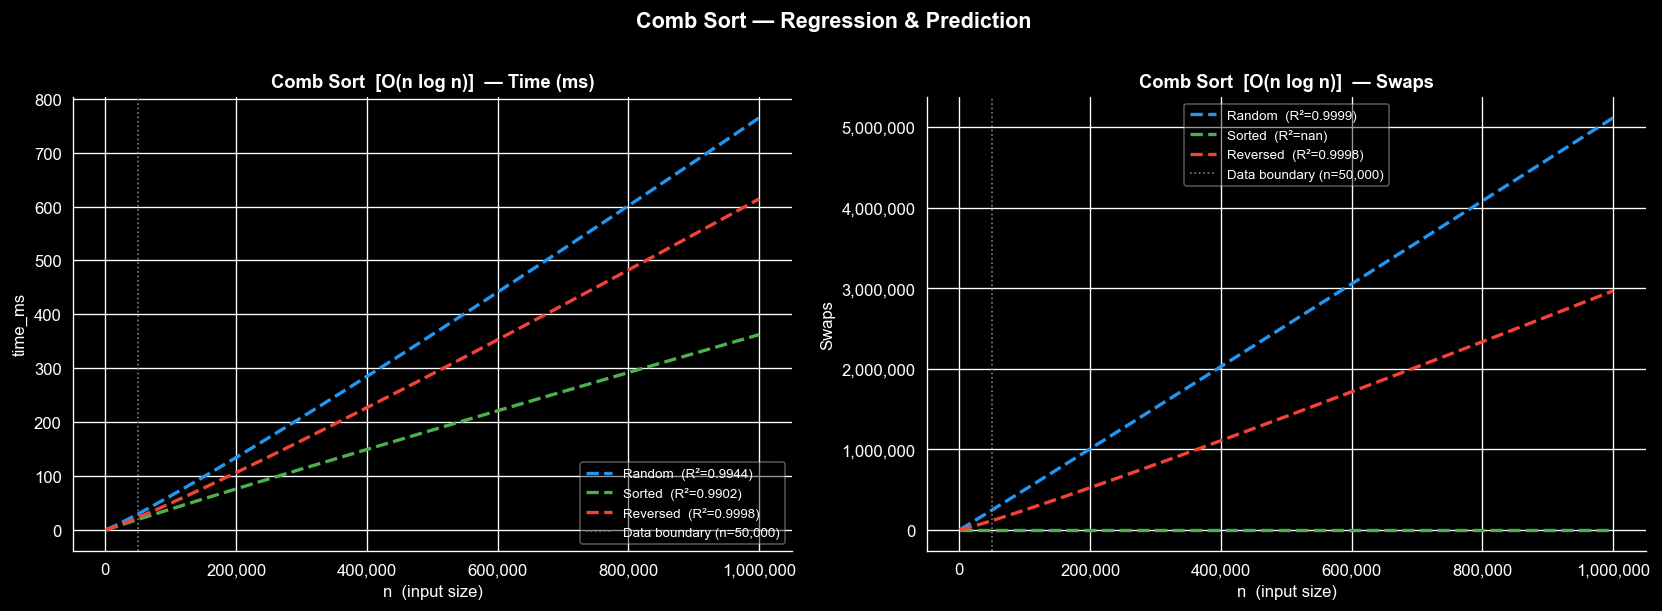

In [26]:
# ── Comb Sort ──
fig, (ax_t, ax_c) = plt.subplots(1, 2, figsize=(14, 5))
fit_and_plot('Comb Sort', ax_t, ax_c)
fig.suptitle('Comb Sort — Regression & Prediction', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

C:\Users\sebig\AppData\Local\Temp\ipykernel_9504\2243927578.py:83: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_c, _ = curve_fit(model_fn, n_vals, c_vals,
C:\Users\sebig\AppData\Local\Temp\ipykernel_9504\2243927578.py:86: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r2_c      = pearsonr(c_vals, model_fn(n_vals, *popt_c))[0] ** 2


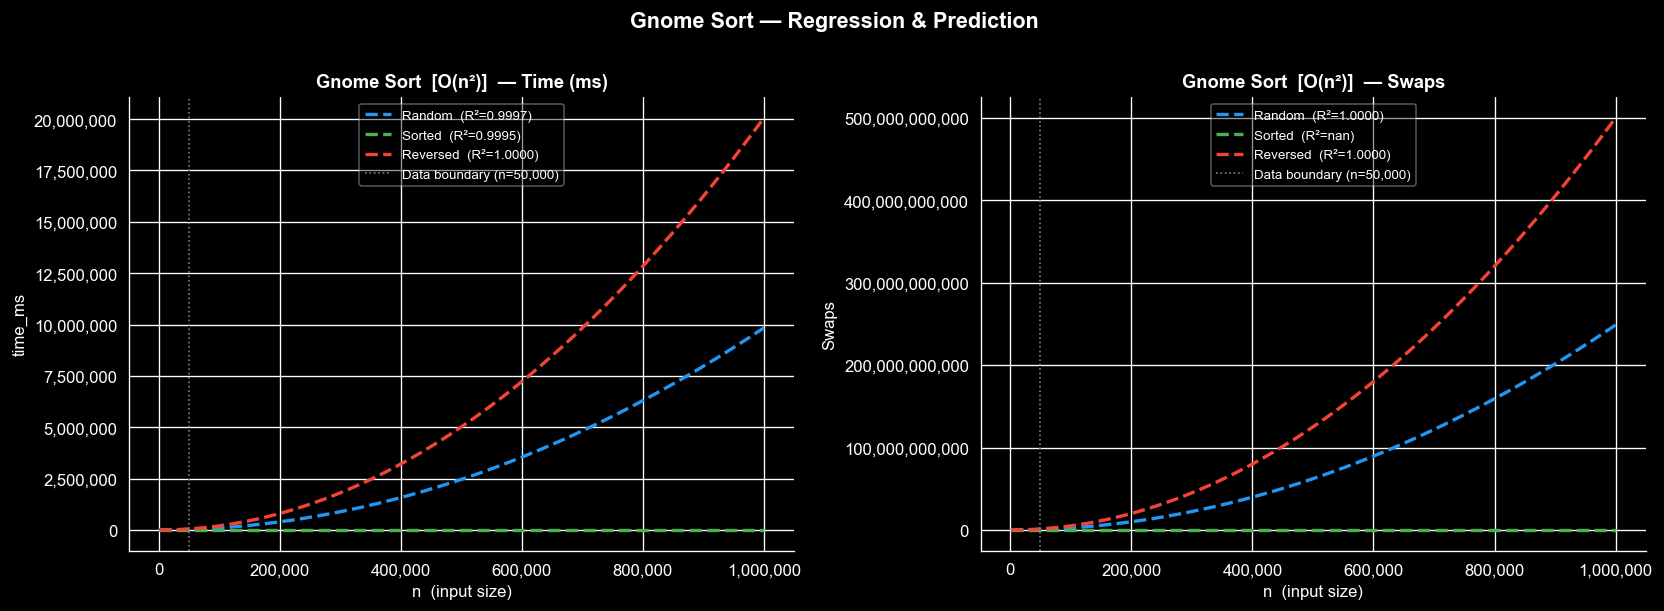

In [27]:
# ── Gnome Sort ──
fig, (ax_t, ax_c) = plt.subplots(1, 2, figsize=(14, 5))
fit_and_plot('Gnome Sort', ax_t, ax_c)
fig.suptitle('Gnome Sort — Regression & Prediction', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

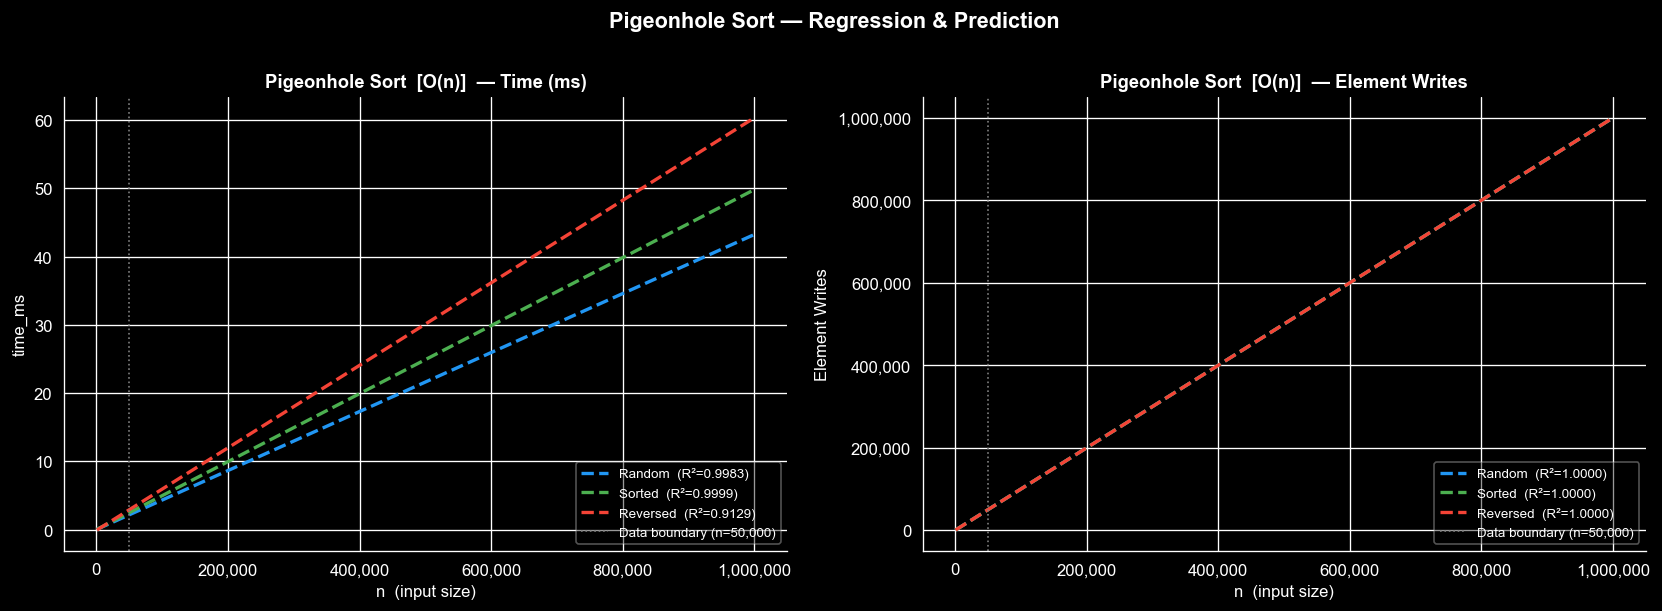

In [28]:
# ── Pigeonhole Sort ──
fig, (ax_t, ax_c) = plt.subplots(1, 2, figsize=(14, 5))
fit_and_plot('Pigeonhole Sort', ax_t, ax_c)
fig.suptitle('Pigeonhole Sort — Regression & Prediction', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()